<a href="https://colab.research.google.com/github/AustinChinn03/DS3001Final/blob/main/PricingAnalyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!git clone https://github.com/AustinChinn03/DS3001Final.git

Cloning into 'DS3001Final'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 24 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 189.46 KiB | 4.74 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [2]:
air_fryers = pd.read_csv("DS3001Final/air_fryers_clean_brand_year.csv")
air_fryers

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.000000,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.000000,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.000000,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.000000,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.000000,0.129398,0.128490,0.000000,15076,0.292186,-1.230364
5,air_fryers,2019,instant_pot,238,13,78.019945,4.364286,0.542017,0.000000,0.550420,0.000000,0.000000,15076,0.015787,-4.148589
6,air_fryers,2019,ninja,2904,18,112.158374,4.778650,0.994490,0.000000,0.000000,0.000000,0.000000,15076,0.192624,-1.647015
7,air_fryers,2019,nuwave,484,15,151.099937,4.321901,0.993802,0.000000,0.561983,0.111570,0.000000,15076,0.032104,-3.438774
8,air_fryers,2019,oster,506,5,191.943688,4.380830,1.000000,0.000000,0.772727,0.000000,0.000000,15076,0.033563,-3.394323
9,air_fryers,2019,ultrean,755,4,80.624675,4.618013,1.000000,0.000000,0.835762,0.000000,0.000000,15076,0.050080,-2.994142


In [4]:
char_cols = [
    'compact_share', 'dual_basket_share', 'oven_style_share',
    'rotisserie_share', 'window_share'
]
brand_dummies = pd.get_dummies(air_fryers['brand'], prefix='brand', drop_first=True)
year_dummies  = pd.get_dummies(air_fryers['year'].astype(str), prefix='year', drop_first=True)

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
X = pd.concat(
    [air_fryers[['avg_price', 'avg_rating'] + char_cols], brand_dummies, year_dummies],
    axis=1
).astype(float)

y = air_fryers['log_brand_share'].astype(float)

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)


In [6]:
coef = pd.Series(model.coef_, index=X.columns)
coef.sort_values(ascending=False)
price_coef = coef['avg_price']

In [7]:
brand_coefs = coef[coef.index.str.startswith('brand_')]
brand_coefs

,0
brand_cosori,2.551946
brand_cuisinart,6.422436
brand_dash,0.176655
brand_gowise usa,3.938996
brand_instant_pot,4.626260
brand_ninja,5.838705
brand_nuwave,3.544883
brand_oster,3.928074
brand_ultrean,0.942399


In [8]:
year_coefs = coef[coef.index.str.startswith('year_')]
r2 = r2_score(y, y_pred)

In [9]:
predicted_log_share = y_pred

coef_table = pd.DataFrame({
    'feature':     X.columns,
    'coefficient': model.coef_
})


In [10]:
price_coef = coef_table.loc[coef_table["feature"] == "avg_price", "coefficient"].iloc[0]
print("Estimated price coefficient:", price_coef)


Estimated price coefficient: -0.03766765298429383


In [14]:
results = air_fryers.copy()
results["predicted_log_share"] = predicted_log_share
results["demand_slope"] = price_coef * results["brand_share"] * (1 - results["brand_share"])
results["unit_cost"] = results["avg_price"] + results["brand_share"] / results["demand_slope"]
results["markup"] = results["avg_price"] - results["unit_cost"]
results["average_profit"] = results["brand_share"] * results["markup"]
results["profit_derivative"] = (
    results["demand_slope"] * results["markup"] + results["brand_share"]
)

print(results[["unit_cost", "markup", "average_profit", "profit_derivative"]].describe())

        unit_cost     markup  average_profit  profit_derivative
count   50.000000  50.000000       50.000000       5.000000e+01
mean    93.102239  29.703894        3.155916       2.985893e-18
std     51.696080   2.615822        2.615822       1.753363e-17
min     22.002913  26.567362        0.019385      -2.775558e-17
25%     53.159061  27.952365        1.404387      -3.903128e-18
50%     70.038270  28.813285        2.265308       0.000000e+00
75%    123.561937  30.956852        4.408875       1.214306e-17
max    199.729962  37.507010       10.959033       5.551115e-17


Question 1

In [20]:
brand_avg = (
    results.groupby('brand')[['unit_cost', 'markup', 'average_profit']]
    .mean()
    .sort_values('unit_cost', ascending=False)
)
print("Avg unit cost & markup by brand:")
print(brand_avg)

Avg unit cost & markup by brand:
              unit_cost     markup  average_profit
brand                                             
cuisinart    194.896119  29.050974        2.502997
oster        161.804969  27.226315        0.678338
ninja        112.488470  32.854071        6.306093
nuwave       109.053549  27.970835        1.422858
cosori        86.283321  27.984628        1.436651
instant_pot   71.903119  32.558234        6.010256
chefman       61.569466  29.368946        2.820968
gowise usa    56.301040  31.153741        4.605764
ultrean       48.785765  29.328841        2.780864
dash          27.936578  29.542349        2.994372


Question 2

In [21]:
neg = results[results['unit_cost'] < 0][['brand', 'year', 'avg_price', 'unit_cost']]
print(f"Negative unit costs: {len(neg)}")
if len(neg):
    print(neg)

Negative unit costs: 0


Question 3

In [41]:
brand_means = results.groupby('brand').agg(
    unit_cost=('unit_cost', 'mean'),
    avg_price=('avg_price', 'mean'),
    avg_rating=('avg_rating', 'mean'),
).reset_index().sort_values('unit_cost', ascending=False)

print("Brands by avg unit cost:")
print(brand_means)

Brands by avg unit cost:
         brand   unit_cost   avg_price  avg_rating
2    cuisinart  194.896119  223.947093    4.438892
8        oster  161.804969  189.031284    4.388653
6        ninja  112.488470  145.342541    4.742064
7       nuwave  109.053549  137.024384    4.389798
1       cosori   86.283321  114.267950    4.656292
5  instant_pot   71.903119  104.461353    4.559323
0      chefman   61.569466   90.938411    4.427966
4   gowise usa   56.301040   87.454781    4.576990
9      ultrean   48.785765   78.114606    4.672616
3         dash   27.936578   57.478927    4.476394


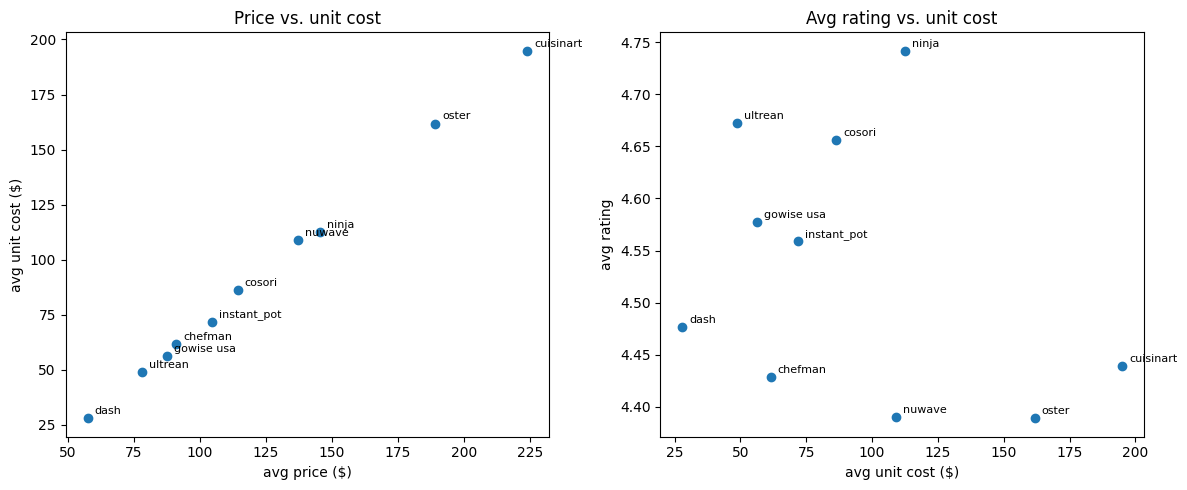

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# price vs unit cost
axes[0].scatter(brand_means['avg_price'], brand_means['unit_cost'])
for _, row in brand_means.iterrows():
    axes[0].annotate(row['brand'], (row['avg_price'], row['unit_cost']),
                     fontsize=8, xytext=(5, 3), textcoords='offset points')
axes[0].set_xlabel('avg price ($)')
axes[0].set_ylabel('avg unit cost ($)')
axes[0].set_title('Price vs. unit cost')

# avg rating vs unit cost
axes[1].scatter(brand_means['unit_cost'], brand_means['avg_rating'])
for _, row in brand_means.iterrows():
    axes[1].annotate(row['brand'], (row['unit_cost'], row['avg_rating']),
                     fontsize=8, xytext=(5, 3), textcoords='offset points')
axes[1].set_xlabel('avg unit cost ($)')
axes[1].set_ylabel('avg rating')
axes[1].set_title('Avg rating vs. unit cost')

plt.tight_layout()
plt.show()

In [43]:
corr_pc = brand_means['avg_price'].corr(brand_means['unit_cost'])
corr_rc = brand_means['avg_rating'].corr(brand_means['unit_cost'])
print(f"\nprice–cost correlation:  {corr_pc:.3f}")
print(f"rating–cost correlation: {corr_rc:.3f}")


price–cost correlation:  0.999
rating–cost correlation: -0.332


Weak negative correlation between cost of product and rating, so no more expensive products do not have higher consumer satisfaction.

Question 4

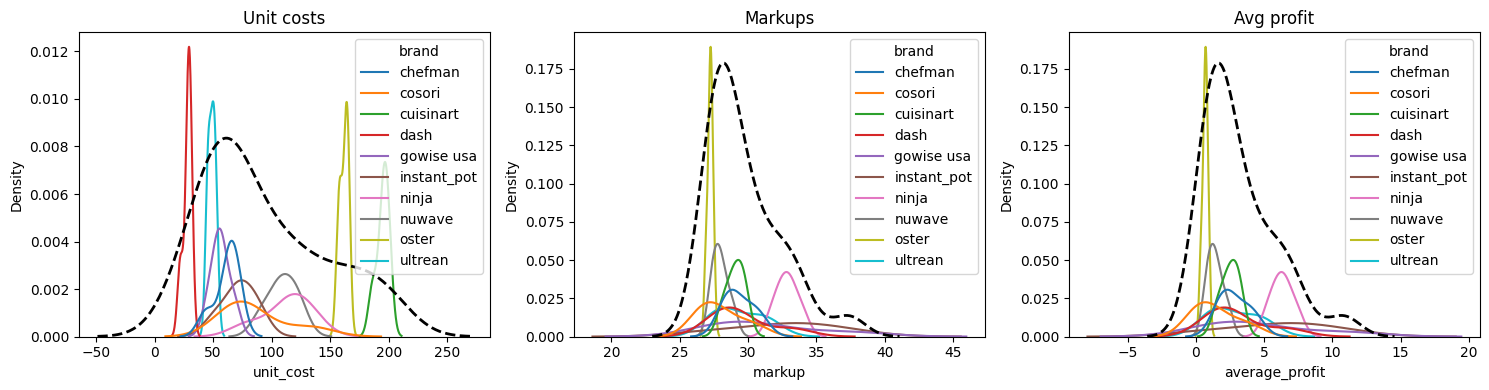

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fields  = ['unit_cost', 'markup', 'average_profit']
titles  = ['Unit costs', 'Markups', 'Avg profit']

for ax, field, title in zip(axes, fields, titles):
    sns.kdeplot(data=results, x=field, hue='brand', ax=ax)
    sns.kdeplot(data=results, x=field, ax=ax,
                color='black', linewidth=2, linestyle='--', label='overall')
    ax.set_title(title)
    ax.set_xlabel(field)

plt.tight_layout()
plt.show()

Question 5

In [51]:
profit_rank = (
    results.groupby('brand')['average_profit']
    .mean()
    .sort_values(ascending=True)
)

print(profit_rank)

brand
oster          0.678338
nuwave         1.422858
cosori         1.436651
cuisinart      2.502997
ultrean        2.780864
chefman        2.820968
dash           2.994372
gowise usa     4.605764
instant_pot    6.010256
ninja          6.306093
Name: average_profit, dtype: float64


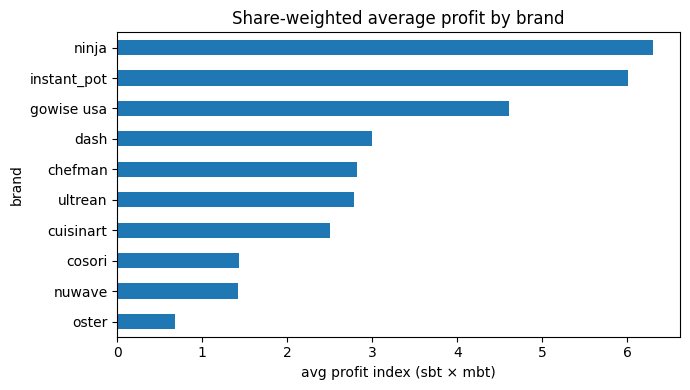

In [52]:
profit_rank.plot(kind='barh', figsize=(7, 4))
plt.xlabel('avg profit index (sbt × mbt)')
plt.title('Share-weighted average profit by brand')
plt.tight_layout()
plt.show()